Mata Kuliah Data Mining 2024 A

Dosen Pengampu: Moh. Khoridatul Huda, S.Pd., M.Si., Ph.D.

Kelompok 8:

1. Nor Hofifah (24031554009)

2. Zahra Brillianty Putri (24031554014)

3. Khofifah Dwi Sanni El Randi (24031554156)

4. Muhammad Khoirul Ilham (24031554193)


Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database


## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

## **Load Dataset**

In [ ]:
df = pd.read_csv('diabetes.csv')

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


## **Cek Dataset**

In [ ]:
print("Jumlah baris, kolom:")
print(df.shape)

Jumlah baris, kolom:
(768, 9)


In [ ]:
print("Struktur Dataset:")
print(df.info())

Struktur Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


## **Statistik Deskriptif**

In [ ]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

## **EDA**

Outcome
0    500
1    268
Name: count, dtype: int64


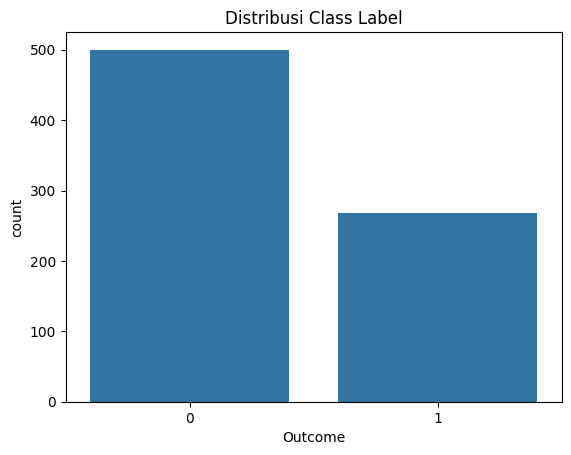

In [ ]:
print(df['Outcome'].value_counts())
sns.countplot(x='Outcome', data=df)
plt.title("Distribusi Class Label")
plt.show()

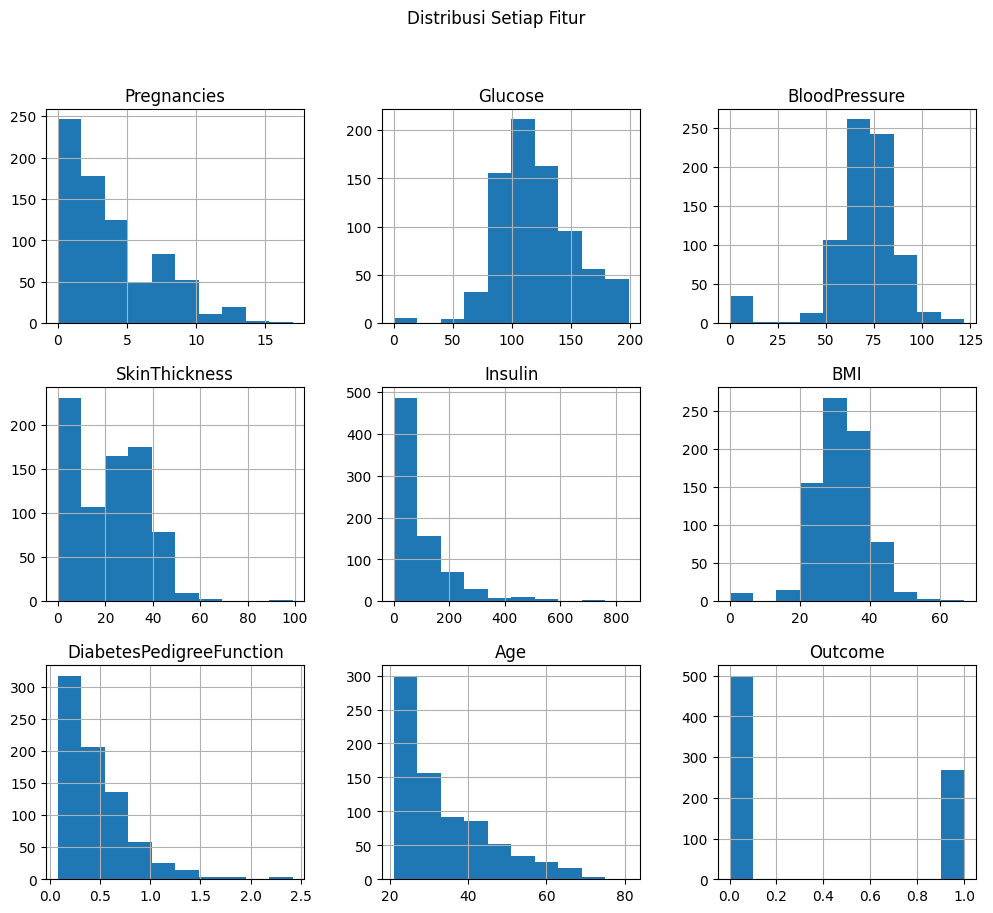

In [ ]:
df.hist(figsize=(12,10))
plt.suptitle("Distribusi Setiap Fitur")
plt.show()

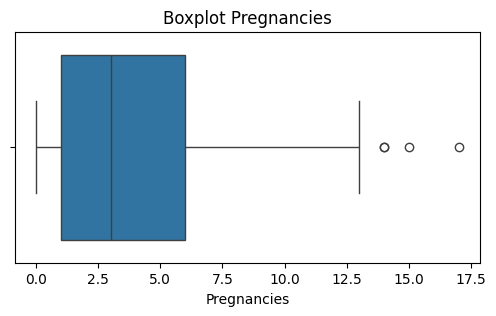

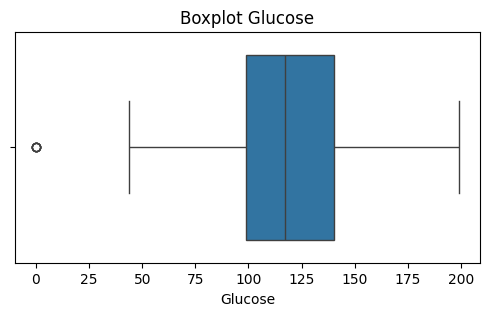

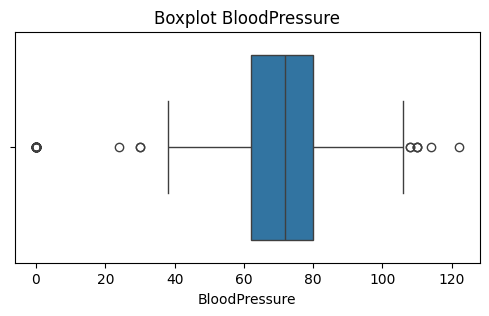

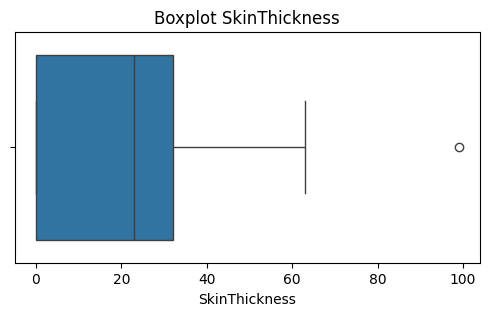

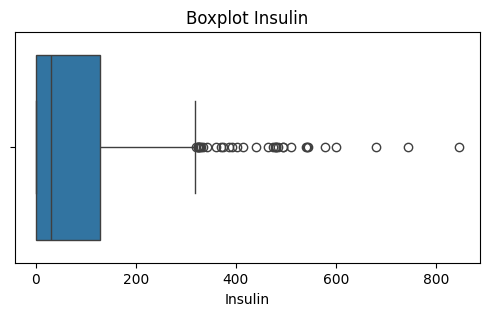

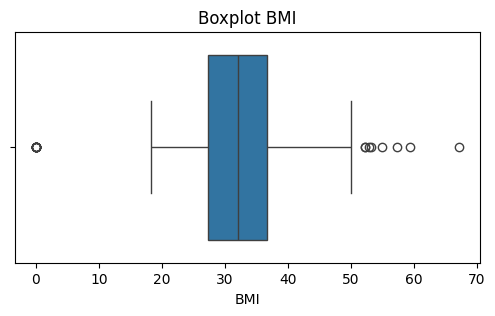

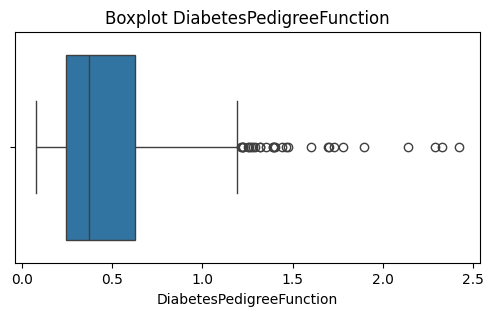

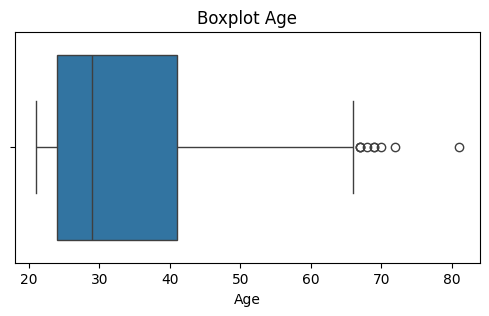

In [ ]:
for col in df.columns[:-1]: # Boxplot untuk melihat outlier
  plt.figure(figsize=(6,3))
  sns.boxplot(x=df[col])

  plt.title(f'Boxplot {col}')
  plt.show()

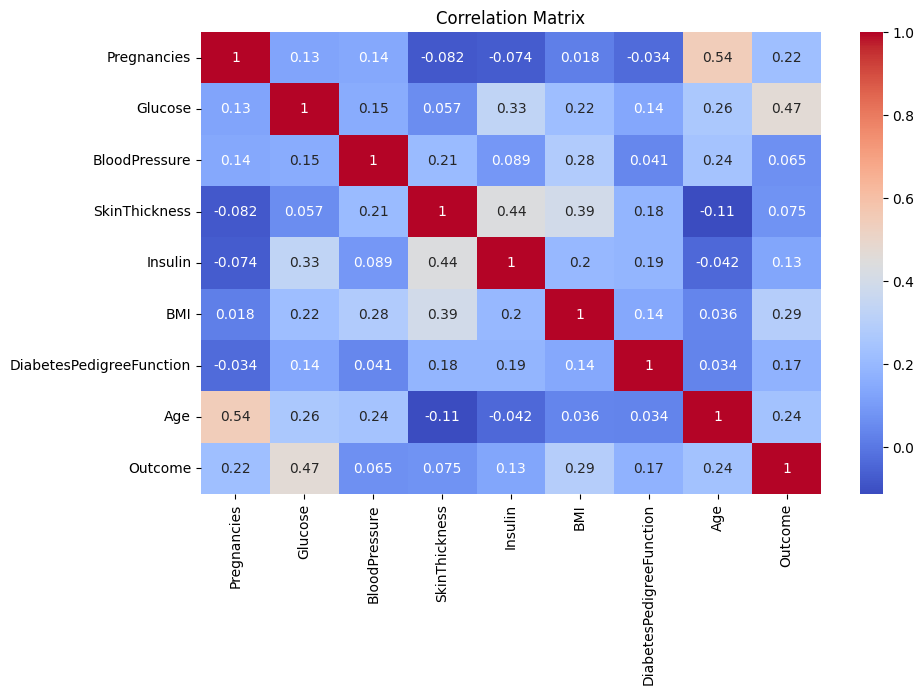

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## **Preprocessing**

In [ ]:
print("Jumlah Missing Value:")
print(df.isnull().sum())

Jumlah Missing Value:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
kolom_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for kolom in kolom_missing:
    df[kolom] = df[kolom].replace(0, np.nan)

In [ ]:
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase': missing_percent
})

print(missing_table)

                          Jumlah Missing  Persentase
Pregnancies                            0    0.000000
Glucose                                5    0.651042
BloodPressure                         35    4.557292
SkinThickness                        227   29.557292
Insulin                              374   48.697917
BMI                                   11    1.432292
DiabetesPedigreeFunction               0    0.000000
Age                                    0    0.000000
Outcome                                0    0.000000


In [ ]:
df.to_csv("data_preprocessing.csv", index=False)

## **Imputasi Median**

In [ ]:
df_median = pd.read_csv('data_preprocessing.csv')

In [ ]:
imputer_median = SimpleImputer(strategy='median')
df_median_imput = pd.DataFrame(imputer_median.fit_transform(df_median), columns=df_median.columns)

In [ ]:
display(df_median_imput.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0


In [ ]:
print("Missing Value Setelah Imputasi Median:")
print(df_median_imput.isnull().sum())

Missing Value Setelah Imputasi Median:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
df_median_imput.to_csv("data_median.csv", index=False)

## **Imputasi Mean**

In [ ]:
df_mean = pd.read_csv('data_preprocessing.csv')

In [ ]:
imputer_mean = SimpleImputer(strategy='mean')
df_mean_imput = pd.DataFrame(imputer_mean.fit_transform(df_mean), columns=df_mean.columns)

In [ ]:
display(df_mean_imput.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.00000,168.000000,43.1,2.288,33.0,1.0


In [ ]:
print("Missing Value Setelah Imputasi Mean:")
print(df_mean_imput.isnull().sum())

Missing Value Setelah Imputasi Mean:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
df_mean_imput.to_csv("data_mean.csv", index=False)

## **Imputasi KNN**

In [ ]:
df_knn = df.copy()

In [ ]:
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_imput = pd.DataFrame(knn_imputer.fit_transform(df_knn), columns=df_knn.columns)

In [ ]:
display(df_knn_imput.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0


In [ ]:
print("Missing Value Setelah Imputasi KNN:")
print(df_knn_imput.isnull().sum())

Missing Value Setelah Imputasi KNN:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
df_knn_imput.to_csv("data_knn.csv", index=False)

## **Imputasi Mice**

In [ ]:
df_mice = df.copy()

In [ ]:
mice_imputer = IterativeImputer(random_state=42)
df_mice_imput = pd.DataFrame(mice_imputer.fit_transform(df_mice), columns=df_mice.columns)

In [ ]:
display(df_mice_imput.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.000000,218.903553,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.000000,70.314661,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,21.542781,268.507178,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.000000,94.000000,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.000000,168.000000,43.1,2.288,33.0,1.0


In [ ]:
print("Missing Value Setelah Imputasi MICE:")
print(df_mice_imput.isnull().sum())

Missing Value Setelah Imputasi MICE:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
df_mice_imput.to_csv("data_mice.csv", index=False)

## **Normalisasi Data dan Split Dataset**

Median

In [ ]:
X_median = df_median_imput.drop('Outcome', axis=1)
y_median = df_median_imput['Outcome']

In [ ]:
X_train_mdn, X_test_mdn, y_train_mdn, y_test_mdn = train_test_split(
    X_median,
    y_median,
    test_size=0.2,
    random_state=42,
    stratify=y_median
)

In [ ]:
scaler_median = StandardScaler()
X_train_mdn = scaler_median.fit_transform(X_train_mdn)
X_test_mdn = scaler_median.transform(X_test_mdn)

In [ ]:
print(X_train_mdn.shape)
print(X_test_mdn.shape)

(614, 8)
(154, 8)


Mean

In [ ]:
X_mean = df_mean_imput.drop('Outcome', axis=1)
y_mean = df_mean_imput['Outcome']

In [ ]:
X_train_mn, X_test_mn, y_train_mn, y_test_mn = train_test_split(
    X_mean,
    y_mean,
    test_size=0.2,
    random_state=42,
    stratify=y_mean
)

In [ ]:
scaler_mean = StandardScaler()
X_train_mn = scaler_mean.fit_transform(X_train_mn)
X_test_mn = scaler_mean.transform(X_test_mn)

In [ ]:
print(X_train_mn.shape)
print(X_test_mn.shape)

(614, 8)
(154, 8)


KNN

In [ ]:
X_knn = df_knn_imput.drop("Outcome", axis=1)
y_knn = df_knn_imput["Outcome"]

In [ ]:
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn,
    y_knn,
    test_size=0.2,
    random_state=42,
    stratify=y_knn
)

In [ ]:
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_knn)
X_test_knn = scaler.transform(X_test_knn)

In [ ]:
print(X_train_knn.shape)
print(X_test_knn.shape)

(614, 8)
(154, 8)


Mice

In [ ]:
X_mice = df_mice_imput.drop("Outcome", axis=1)
y_mice = df_mice_imput["Outcome"]

In [ ]:
X_train_mice, X_test_mice, y_train_mice, y_test_mice = train_test_split(
    X_mice,
    y_mice,
    test_size=0.2,
    random_state=42,
    stratify=y_mice
)

In [ ]:
scaler = StandardScaler()
X_train_mice = scaler.fit_transform(X_train_mice)
X_test_mice = scaler.transform(X_test_mice)

In [ ]:
print(X_train_mice.shape)
print(X_test_mice.shape)

(614, 8)
(154, 8)


## **Model 4 Algoritma**

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        C=0.1,
        max_iter=1000,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )

}

## **Train dataset**

In [ ]:
def evaluate_model(X_train, X_test, y_train, y_test, dataset_name):
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        print(f"\nClassification Report - {name} ({dataset_name})")
        print(classification_report(y_test, y_pred))

        results.append({
            "Dataset": dataset_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        })

    return pd.DataFrame(results)

In [ ]:
def get_predictions(X_train, X_test, y_train, y_test):
    predictions = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        predictions[name] = pd.DataFrame({
            "Actual": y_test.values,
            "Predicted": y_pred
        })

    return predictions

## **Evaluasi Model Algoritma**

Datatest Median

In [ ]:
results_median = evaluate_model(
    X_train_mdn, X_test_mdn, y_train_mdn, y_test_mdn,
    "Median"
)

pred_median = get_predictions(
    X_train_mdn, X_test_mdn, y_train_mdn, y_test_mdn
)


Classification Report - Random Forest (Median)
              precision    recall  f1-score   support

         0.0       0.78      0.83      0.81       100
         1.0       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154


Classification Report - Decision Tree (Median)
              precision    recall  f1-score   support

         0.0       0.84      0.79      0.81       100
         1.0       0.65      0.72      0.68        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.77      0.77      0.77       154


Classification Report - Logistic Regression (Median)
              precision    recall  f1-score   support

         0.0       0.76      0.80      0.78       100
         1.0       0.59      0.54      0.56        54

    accuracy                    

Datatest Mean

In [ ]:
results_mean = evaluate_model(
    X_train_mn, X_test_mn, y_train_mn, y_test_mn,
    "Mean"
)

pred_mean = get_predictions(
    X_train_mn, X_test_mn, y_train_mn, y_test_mn
)


Classification Report - Random Forest (Mean)
              precision    recall  f1-score   support

         0.0       0.77      0.82      0.80       100
         1.0       0.62      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154


Classification Report - Decision Tree (Mean)
              precision    recall  f1-score   support

         0.0       0.84      0.79      0.81       100
         1.0       0.65      0.72      0.68        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.77      0.77      0.77       154


Classification Report - Logistic Regression (Mean)
              precision    recall  f1-score   support

         0.0       0.76      0.80      0.78       100
         1.0       0.59      0.54      0.56        54

    accuracy                          

Datatest KNN

In [ ]:
results_knn = evaluate_model(
    X_train_knn, X_test_knn, y_train_knn, y_test_knn,
    "KNN"
)

pred_mice = get_predictions(
    X_train_knn, X_test_knn, y_train_knn, y_test_knn
)


Classification Report - Random Forest (KNN)
              precision    recall  f1-score   support

         0.0       0.76      0.81      0.79       100
         1.0       0.60      0.54      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.68       154
weighted avg       0.71      0.71      0.71       154


Classification Report - Decision Tree (KNN)
              precision    recall  f1-score   support

         0.0       0.78      0.82      0.80       100
         1.0       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154


Classification Report - Logistic Regression (KNN)
              precision    recall  f1-score   support

         0.0       0.75      0.80      0.77       100
         1.0       0.57      0.50      0.53        54

    accuracy                           0.

Datatest Mice

In [ ]:
results_mice = evaluate_model(
    X_train_mice, X_test_mice, y_train_mice, y_test_mice,
    "MICE"
)

pred_mice = get_predictions(
    X_train_mice, X_test_mice, y_train_mice, y_test_mice
)


Classification Report - Random Forest (MICE)
              precision    recall  f1-score   support

         0.0       0.78      0.79      0.79       100
         1.0       0.60      0.59      0.60        54

    accuracy                           0.72       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154


Classification Report - Decision Tree (MICE)
              precision    recall  f1-score   support

         0.0       0.76      0.81      0.78       100
         1.0       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Classification Report - Logistic Regression (MICE)
              precision    recall  f1-score   support

         0.0       0.75      0.80      0.77       100
         1.0       0.57      0.50      0.53        54

    accuracy                          

## **Cross Validation**

In [ ]:
def fold_table(X, y, dataset_name):

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    rows = []

    for name, model in models.items():

        scores = []

        for fold, (train_idx, test_idx) in enumerate(
            kf.split(X),
            start=1
        ):

            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            acc = accuracy_score(
                y_test,
                y_pred
            )

            scores.append(acc)

            rows.append({
                "Dataset": dataset_name,
                "Model": name,
                "Fold": fold,
                "Accuracy": acc
            })

    return pd.DataFrame(rows)

In [ ]:
fold_results = pd.concat([
    fold_table(X_mean, y_mean, "Mean"),
    fold_table(X_median, y_median, "Median"),
    fold_table(X_knn, y_knn, "KNN"),
    fold_table(X_mice, y_mice, "MICE")
], ignore_index=True)

display(fold_results)

,Dataset,Model,Fold,Accuracy
0,Mean,Random Forest,1,0.740260
1,Mean,Random Forest,2,0.785714
2,Mean,Random Forest,3,0.792208
3,Mean,Random Forest,4,0.758170
4,Mean,Random Forest,5,0.745098
...,...,...,...,...
75,MICE,XGBoost,1,0.746753
76,MICE,XGBoost,2,0.779221
77,MICE,XGBoost,3,0.759740
78,MICE,XGBoost,4,0.777778


## **Hasil Evaluasi**

In [ ]:
cv_results = (
    fold_results
    .groupby(["Dataset", "Model"])["Accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)

cv_results.columns = [
    "Dataset",
    "Model",
    "CV Accuracy Mean",
    "CV Accuracy Std"
]

cv_results["CV Accuracy Mean"] = cv_results["CV Accuracy Mean"].round(4)
cv_results["CV Accuracy Std"] = cv_results["CV Accuracy Std"].round(4)

display(cv_results)

,Dataset,Model,CV Accuracy Mean,CV Accuracy Std
0,KNN,Decision Tree,0.7344,0.0213
1,KNN,Logistic Regression,0.7683,0.0353
2,KNN,Random Forest,0.7630,0.0249
3,KNN,XGBoost,0.7591,0.0217
4,MICE,Decision Tree,0.7552,0.0185
5,MICE,Logistic Regression,0.7696,0.0324
6,MICE,Random Forest,0.7708,0.0268
7,MICE,XGBoost,0.7656,0.0135
8,Mean,Decision Tree,0.7487,0.0233
9,Mean,Logistic Regression,0.7722,0.0331


## **Hasil Prediksi dengan aktual**



In [ ]:
print(pred_median["Random Forest"].head())
print(pred_mean["Random Forest"].head())
print(pred_knn["Random Forest"].head())
print(pred_mice["Random Forest"].head())

   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0
   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0
   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0
   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0


In [ ]:
print(pred_median["Decision Tree"].head())
print(pred_mean["Decision Tree"].head())
print(pred_knn["Decision Tree"].head())
print(pred_mice["Decision Tree"].head())

   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        1.0
4     0.0        0.0
   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        1.0
4     0.0        0.0
   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0
   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0


In [ ]:
print(pred_median["Logistic Regression"].head())
print(pred_mean["Logistic Regression"].head())
print(pred_knn["Logistic Regression"].head())
print(pred_mice["Logistic Regression"].head())

   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0
   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0
   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0
   Actual  Predicted
0     0.0        1.0
1     0.0        0.0
2     0.0        0.0
3     1.0        0.0
4     0.0        0.0


In [ ]:
print(pred_median["XGBoost"].head())
print(pred_mean["XGBoost"].head())
print(pred_knn["XGBoost"].head())
print(pred_mice["XGBoost"].head())

   Actual  Predicted
0     0.0          1
1     0.0          0
2     0.0          0
3     1.0          0
4     0.0          0
   Actual  Predicted
0     0.0          1
1     0.0          0
2     0.0          0
3     1.0          0
4     0.0          0
   Actual  Predicted
0     0.0          1
1     0.0          0
2     0.0          0
3     1.0          0
4     0.0          0
   Actual  Predicted
0     0.0          1
1     0.0          0
2     0.0          0
3     1.0          0
4     0.0          0


## **Confusion Matrix**

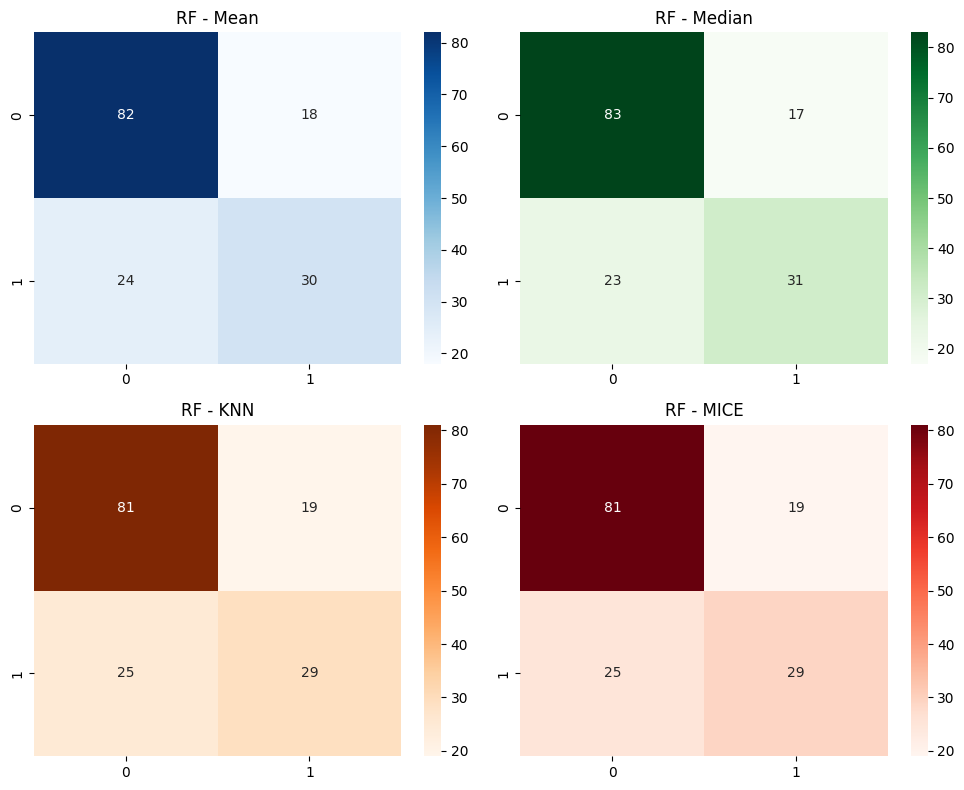

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,8))

# Mean
cm_mean = confusion_matrix(
    y_test_mn,
    pred_mean["Random Forest"]["Predicted"]
)

sns.heatmap(
    cm_mean,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0,0]
)

ax[0,0].set_title("RF - Mean")

# Median
cm_median = confusion_matrix(
    y_test_mdn,
    pred_median["Random Forest"]["Predicted"]
)

sns.heatmap(
    cm_median,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[0,1]
)

ax[0,1].set_title("RF - Median")

# KNN
cm_knn = confusion_matrix(
    y_test_knn,
    pred_knn["Random Forest"]["Predicted"]
)

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=ax[1,0]
)

ax[1,0].set_title("RF - KNN")

# MICE
cm_mice = confusion_matrix(
    y_test_mice,
    pred_mice["Random Forest"]["Predicted"]
)

sns.heatmap(
    cm_mice,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=ax[1,1]
)

ax[1,1].set_title("RF - MICE")

plt.tight_layout()
plt.show()

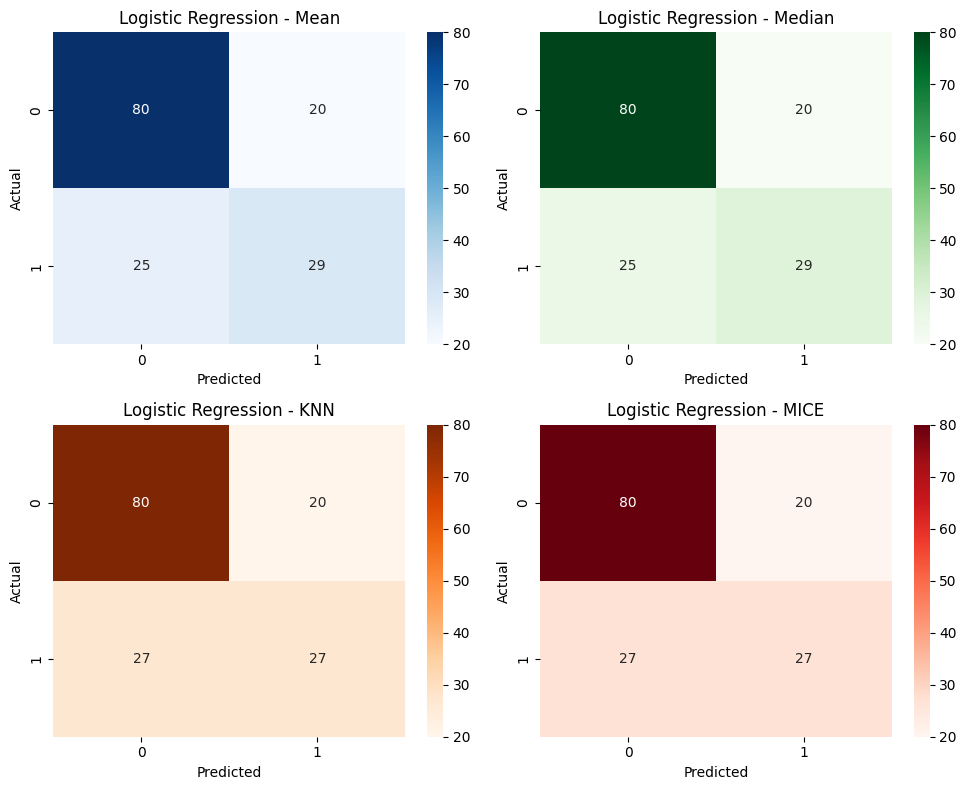

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,8))

# Mean
cm_mean = confusion_matrix(
    y_test_mn,
    pred_mean["Logistic Regression"]["Predicted"]
)

sns.heatmap(
    cm_mean,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0,0]
)

ax[0,0].set_title('Logistic Regression - Mean')
ax[0,0].set_xlabel('Predicted')
ax[0,0].set_ylabel('Actual')


# Median
cm_median = confusion_matrix(
    y_test_mdn,
    pred_median["Logistic Regression"]["Predicted"]
)

sns.heatmap(
    cm_median,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[0,1]
)

ax[0,1].set_title('Logistic Regression - Median')
ax[0,1].set_xlabel('Predicted')
ax[0,1].set_ylabel('Actual')


# KNN
cm_knn = confusion_matrix(
    y_test_knn,
    pred_knn["Logistic Regression"]["Predicted"]
)

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=ax[1,0]
)

ax[1,0].set_title('Logistic Regression - KNN')
ax[1,0].set_xlabel('Predicted')
ax[1,0].set_ylabel('Actual')


# MICE
cm_mice = confusion_matrix(
    y_test_mice,
    pred_mice["Logistic Regression"]["Predicted"]
)

sns.heatmap(
    cm_mice,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=ax[1,1]
)

ax[1,1].set_title('Logistic Regression - MICE')
ax[1,1].set_xlabel('Predicted')
ax[1,1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

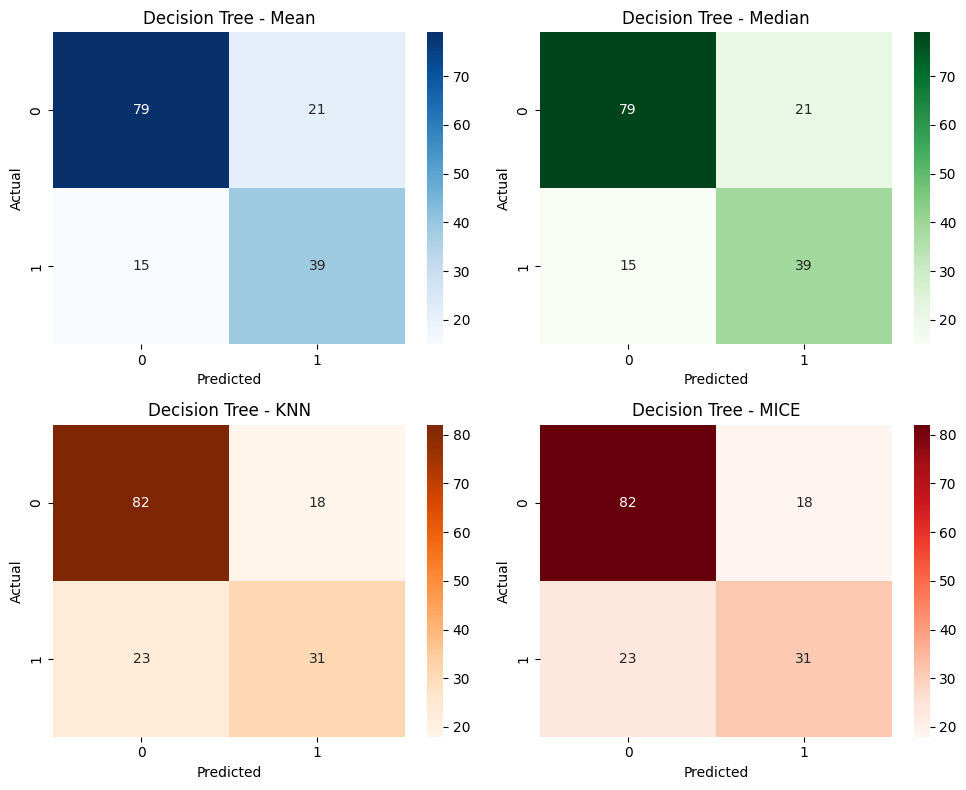

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,8))

# Mean
cm_mean = confusion_matrix(
    y_test_mn,
    pred_mean["Decision Tree"]["Predicted"]
)

sns.heatmap(
    cm_mean,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0,0]
)

ax[0,0].set_title('Decision Tree - Mean')
ax[0,0].set_xlabel('Predicted')
ax[0,0].set_ylabel('Actual')


# Median
cm_median = confusion_matrix(
    y_test_mdn,
    pred_median["Decision Tree"]["Predicted"]
)

sns.heatmap(
    cm_median,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[0,1]
)

ax[0,1].set_title('Decision Tree - Median')
ax[0,1].set_xlabel('Predicted')
ax[0,1].set_ylabel('Actual')


# KNN
cm_knn = confusion_matrix(
    y_test_knn,
    pred_knn["Decision Tree"]["Predicted"]
)

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=ax[1,0]
)

ax[1,0].set_title('Decision Tree - KNN')
ax[1,0].set_xlabel('Predicted')
ax[1,0].set_ylabel('Actual')


# MICE
cm_mice = confusion_matrix(
    y_test_mice,
    pred_mice["Decision Tree"]["Predicted"]
)

sns.heatmap(
    cm_mice,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=ax[1,1]
)

ax[1,1].set_title('Decision Tree - MICE')
ax[1,1].set_xlabel('Predicted')
ax[1,1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

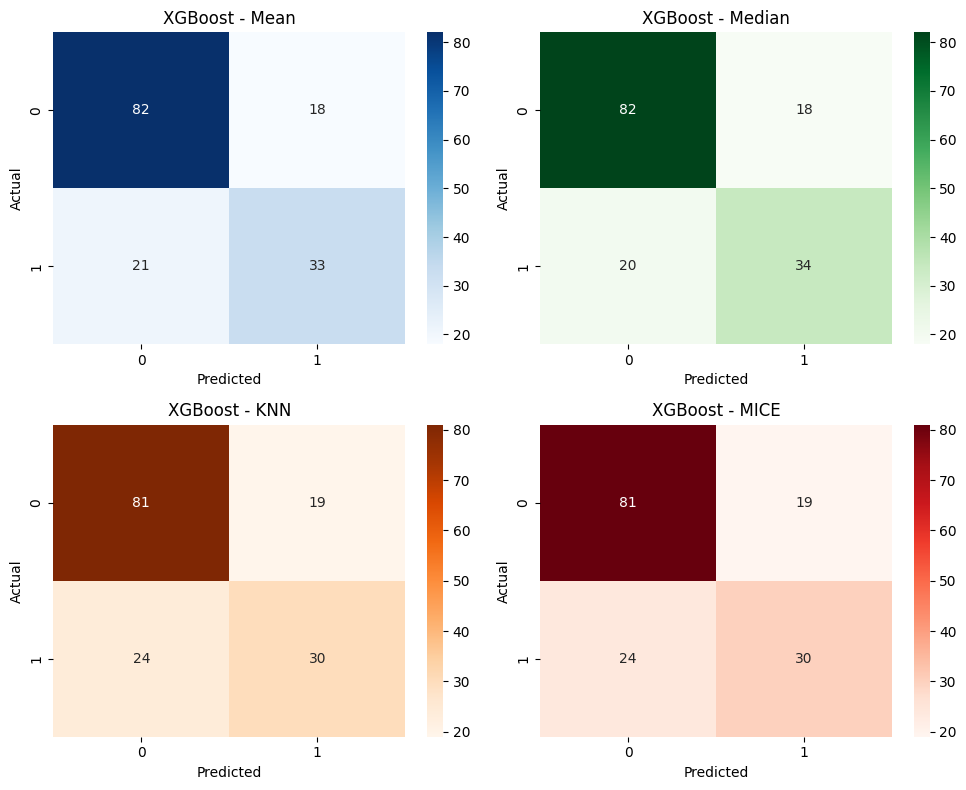

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,8))

cm_mean = confusion_matrix(
    y_test_mn,
    pred_mean["XGBoost"]["Predicted"]
)

sns.heatmap(
    cm_mean,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0,0]
)

ax[0,0].set_title("XGBoost - Mean")
ax[0,0].set_xlabel("Predicted")
ax[0,0].set_ylabel("Actual")


cm_median = confusion_matrix(
    y_test_mdn,
    pred_median["XGBoost"]["Predicted"]
)

sns.heatmap(
    cm_median,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=ax[0,1]
)

ax[0,1].set_title("XGBoost - Median")
ax[0,1].set_xlabel("Predicted")
ax[0,1].set_ylabel("Actual")


cm_knn = confusion_matrix(
    y_test_knn,
    pred_knn["XGBoost"]["Predicted"]
)

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=ax[1,0]
)

ax[1,0].set_title("XGBoost - KNN")
ax[1,0].set_xlabel("Predicted")
ax[1,0].set_ylabel("Actual")


cm_mice = confusion_matrix(
    y_test_mice,
    pred_mice["XGBoost"]["Predicted"]
)

sns.heatmap(
    cm_mice,
    annot=True,
    fmt="d",
    cmap="Reds",
    ax=ax[1,1]
)

ax[1,1].set_title("XGBoost - MICE")
ax[1,1].set_xlabel("Predicted")
ax[1,1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### **Visualisasi Decision Tree**

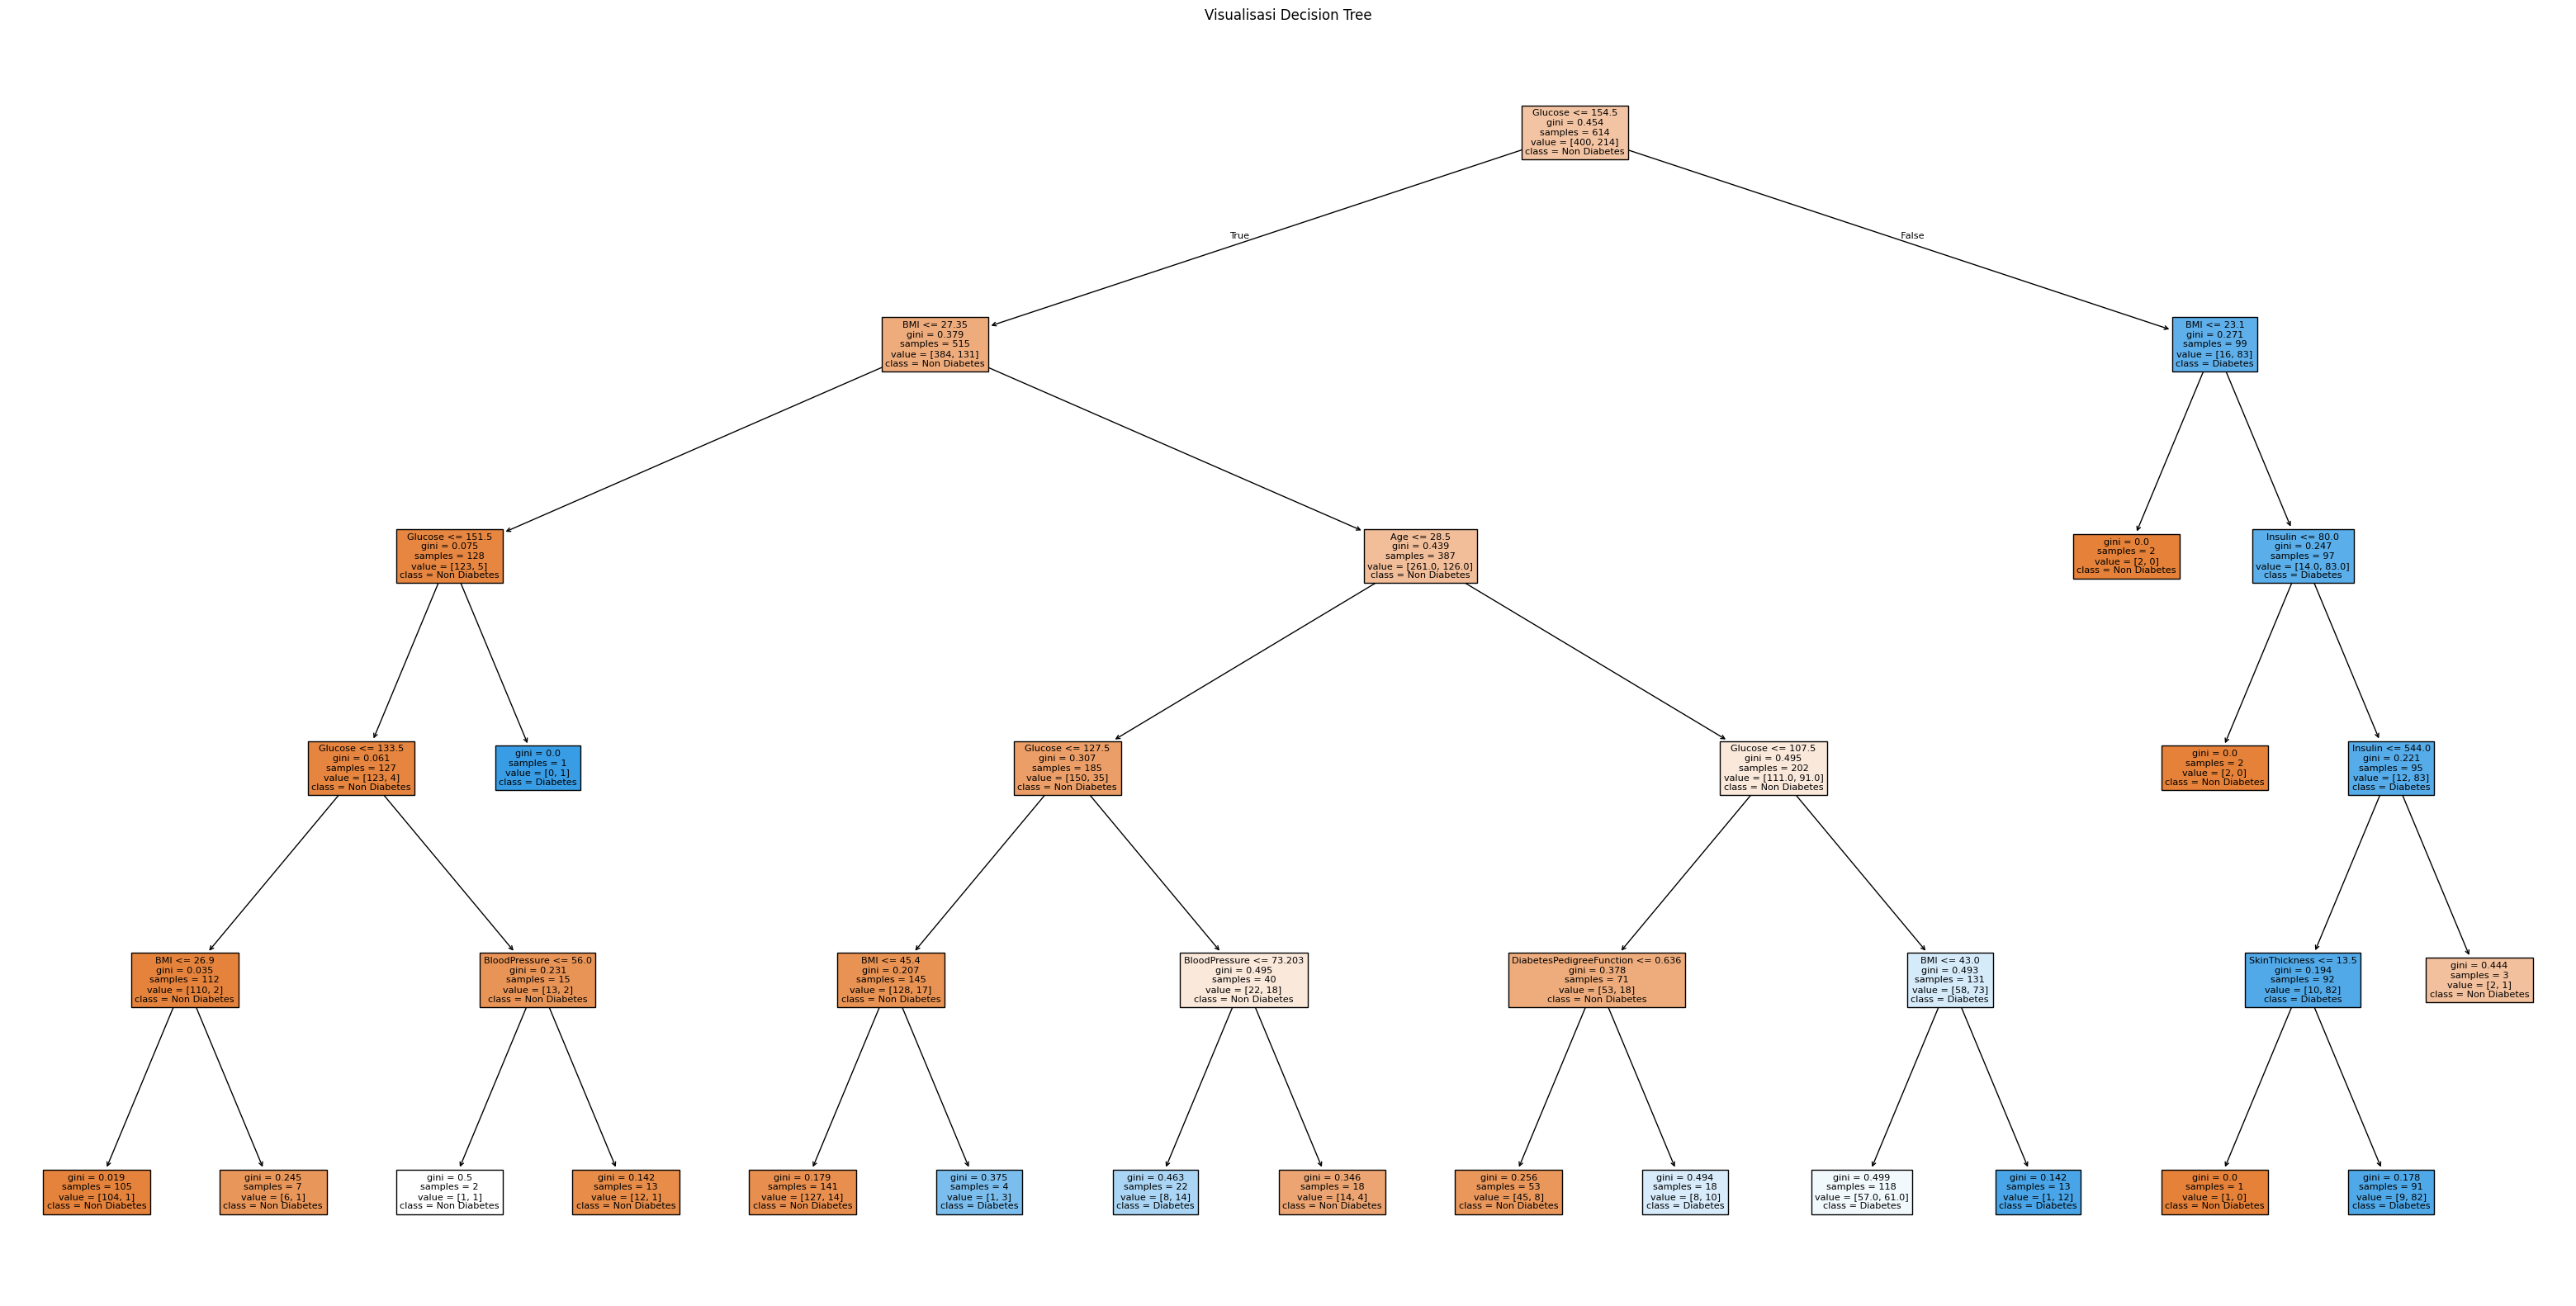

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train_mn, y_train_mn)

plt.figure(figsize=(40,20))

tree.plot_tree(
    dt_model,
    feature_names=X_train_mn.columns,
    class_names=['Non Diabetes', 'Diabetes'],
    filled=True
)

plt.title("Visualisasi Decision Tree")
plt.show()

## **Visualisasi perbandingan**

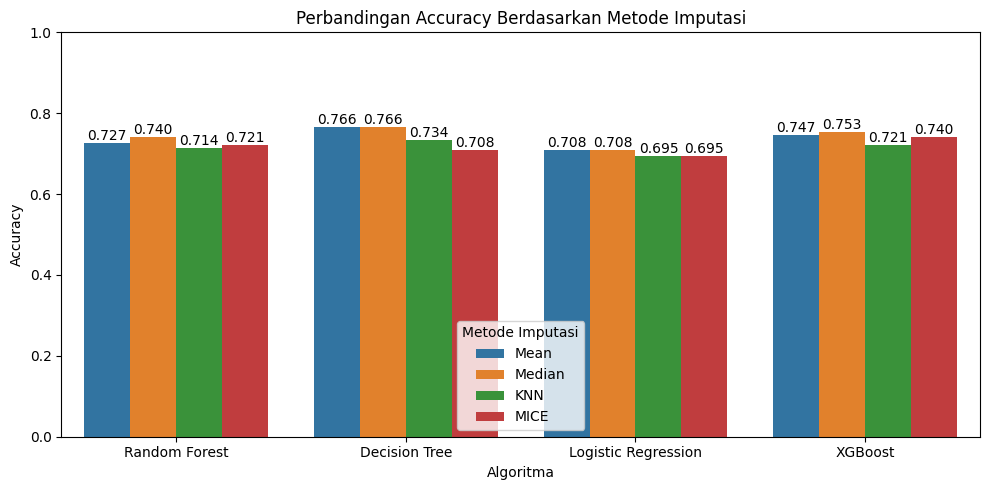

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=final_results,
    x="Model",
    y="Accuracy",
    hue="Dataset"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title("Perbandingan Accuracy Berdasarkan Metode Imputasi")
plt.xlabel("Algoritma")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.legend(title="Metode Imputasi")

plt.tight_layout()
plt.show()

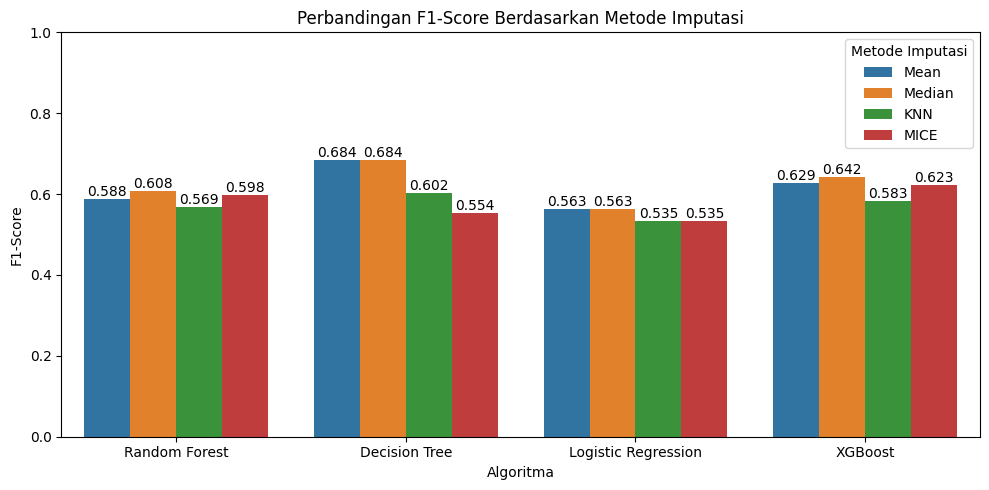

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=final_results,
    x="Model",
    y="F1 Score",
    hue="Dataset"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title("Perbandingan F1-Score Berdasarkan Metode Imputasi")
plt.xlabel("Algoritma")
plt.ylabel("F1-Score")
plt.ylim(0, 1)

plt.legend(title="Metode Imputasi")

plt.tight_layout()
plt.show()

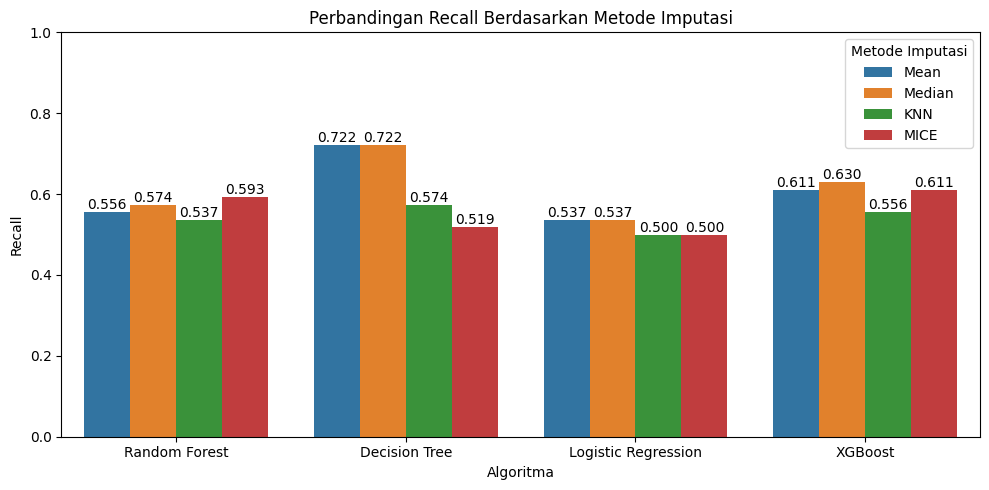

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=final_results,
    x="Model",
    y="Recall",
    hue="Dataset"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title("Perbandingan Recall Berdasarkan Metode Imputasi")
plt.xlabel("Algoritma")
plt.ylabel("Recall")
plt.ylim(0, 1)

plt.legend(title="Metode Imputasi")

plt.tight_layout()
plt.show()

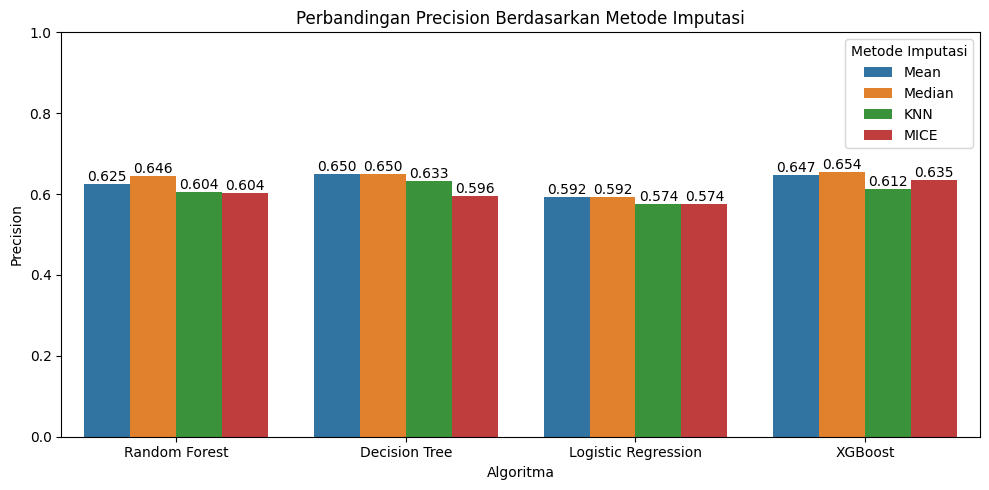

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=final_results,
    x="Model",
    y="Precision",
    hue="Dataset"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title("Perbandingan Precision Berdasarkan Metode Imputasi")
plt.xlabel("Algoritma")
plt.ylabel("Precision")
plt.ylim(0, 1)

plt.legend(title="Metode Imputasi")

plt.tight_layout()
plt.show()

## **Model Terbaik**

In [ ]:
best_model = final_results.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print(
    f"Model terbaik adalah "
    f"{best_model['Model']} "
    f"dengan imputasi "
    f"{best_model['Dataset']}"
)

Model terbaik adalah Decision Tree dengan imputasi Mean


In [ ]:
best_cv = cv_results.loc[
    cv_results["CV Accuracy Mean"].idxmax()
]

print("Model Terbaik Berdasarkan Cross Validation")
print(best_cv)

Model Terbaik Berdasarkan Cross Validation
Dataset                            Mean
Model               Logistic Regression
CV Accuracy Mean                 0.7722
CV Accuracy Std                  0.0331
Name: 9, dtype: object


In [ ]:
best_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

best_model.fit(X_train_mn, y_train_mn)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
explainer = shap.Explainer(
    best_model,
    X_train_mn
)

shap_values = explainer(X_test_mn)

In [ ]:
print(type(shap_values.values))
print(shap_values.values.shape)

<class 'numpy.ndarray'>
(154, 8)


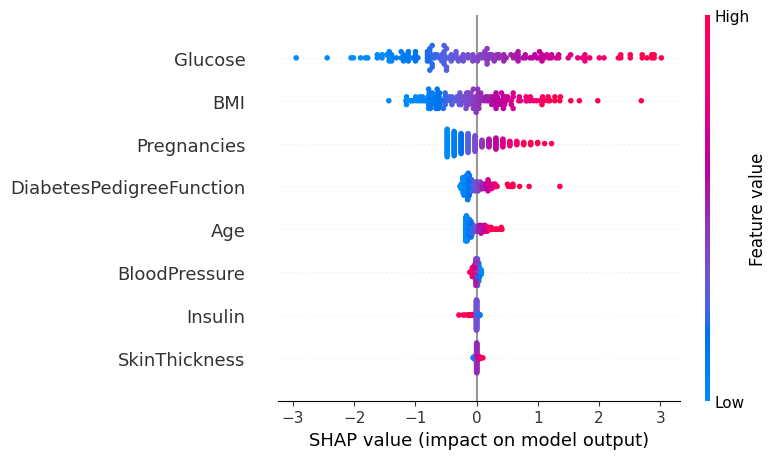

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_mn,
    feature_names=X_mean.columns
)

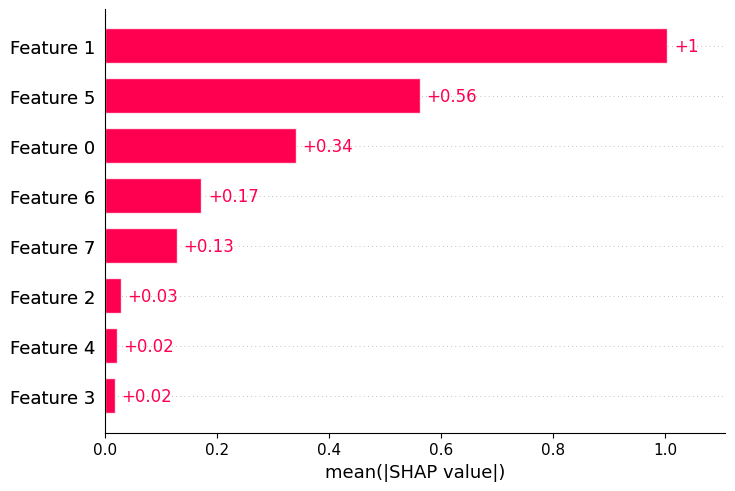

In [ ]:
shap.plots.bar(shap_values)

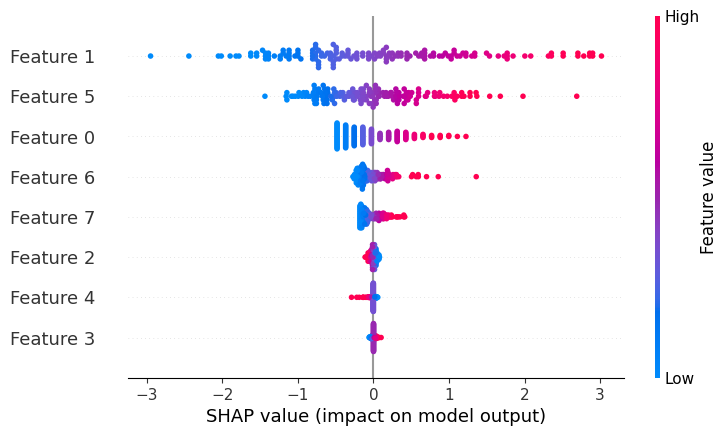

In [ ]:
shap.plots.beeswarm(shap_values)

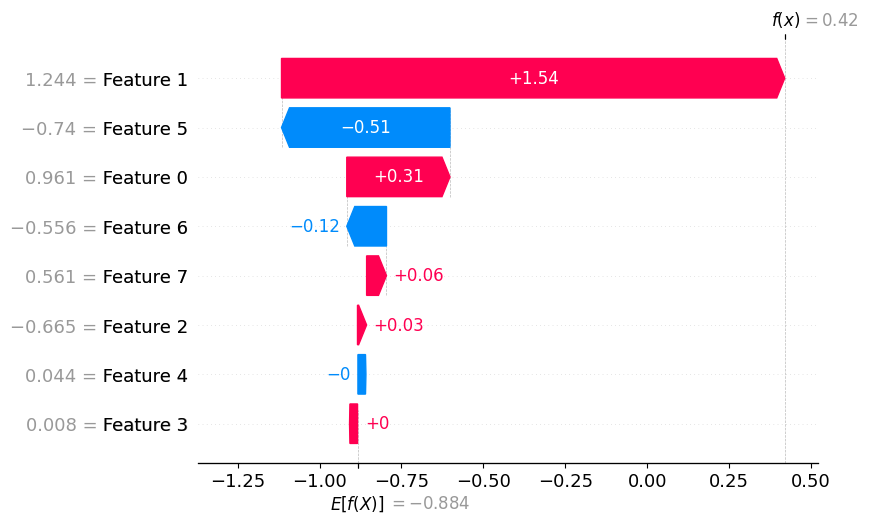

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
importance = pd.DataFrame({
    "Feature": X_mean.columns,
    "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
})

importance = importance.sort_values(
    by="Mean |SHAP|",
    ascending=False
).reset_index(drop=True)

display(importance)

,Feature,Mean |SHAP|
0,Glucose,1.003962
1,BMI,0.561369
2,Pregnancies,0.340441
3,DiabetesPedigreeFunction,0.171466
4,Age,0.127732
5,BloodPressure,0.028348
6,Insulin,0.021150
7,SkinThickness,0.016907


## **Hasil Akhir**

In [ ]:
print(" HASIL AKHIR ")

best_accuracy = final_results.loc[
    final_results["Accuracy"].idxmax()
]

best_cv = cv_results.loc[
    cv_results["CV Accuracy Mean"].idxmax()
]

print("\nModel Terbaik Berdasarkan Test Accuracy")
display(best_accuracy.to_frame().T)

print("\nModel Terbaik Berdasarkan Cross Validation")
display(best_cv.to_frame().T)

 HASIL AKHIR 

Model Terbaik Berdasarkan Test Accuracy


,Dataset,Model,Accuracy,Precision,Recall,F1 Score
1,Mean,Decision Tree,0.766234,0.65,0.722222,0.684211



Model Terbaik Berdasarkan Cross Validation


,Dataset,Model,CV Accuracy Mean,CV Accuracy Std
9,Mean,Logistic Regression,0.7722,0.0331


In [ ]:
final_results.to_csv(
    "hasil_evaluasi_model.csv",
    index=False
)

cv_results.to_csv(
    "hasil_cross_validation.csv",
    index=False
)

importance.to_csv(
    "hasil_shap_importance.csv",
    index=False
)

print("Seluruh hasil berhasil disimpan.")

Seluruh hasil berhasil disimpan.
